# Autoregressive Conditional Heteroskedasticity (ARCH)
- periods of high volatility are followed by periods of even higher volatility
- periods of low volatility are followed by periods of even lower volatility

In practice this means that volatility tends to cluster.

## GARCH
- error varince is thought to be autocorrelated over time
- assume the variance of the error term follows a process based on an autoregressive moving average
- supposed to capture better long-term volatility patterns

## ARCH(q) == GARCH(0, q)

In [32]:
import numpy as np
from arch import arch_model
import pandas as pd
import matplotlib.pyplot as plt
import json

import sys
import os

sys.path.append(os.path.abspath('..'))
from functions import line_plot, mse, mae, rmse, mape, mase, pred_char_to_value

import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
from statsmodels.graphics.tsaplots import plot_pacf

In [33]:
df = pd.read_csv('../Data/aluminium_pre_inputs.csv')

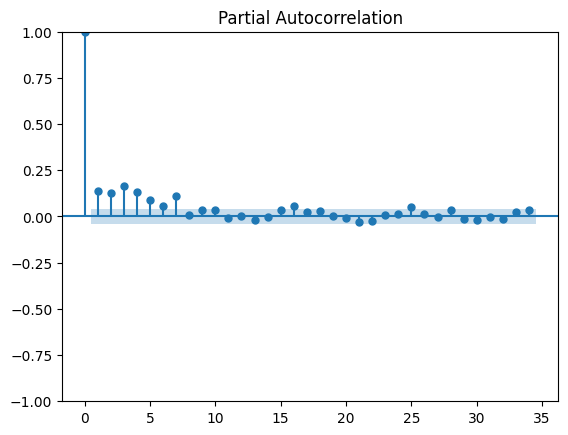

In [3]:
# Partial AutoCorrelation Function
plot_pacf(df['al_lme_prices_log_returns']**2)
plt.show()

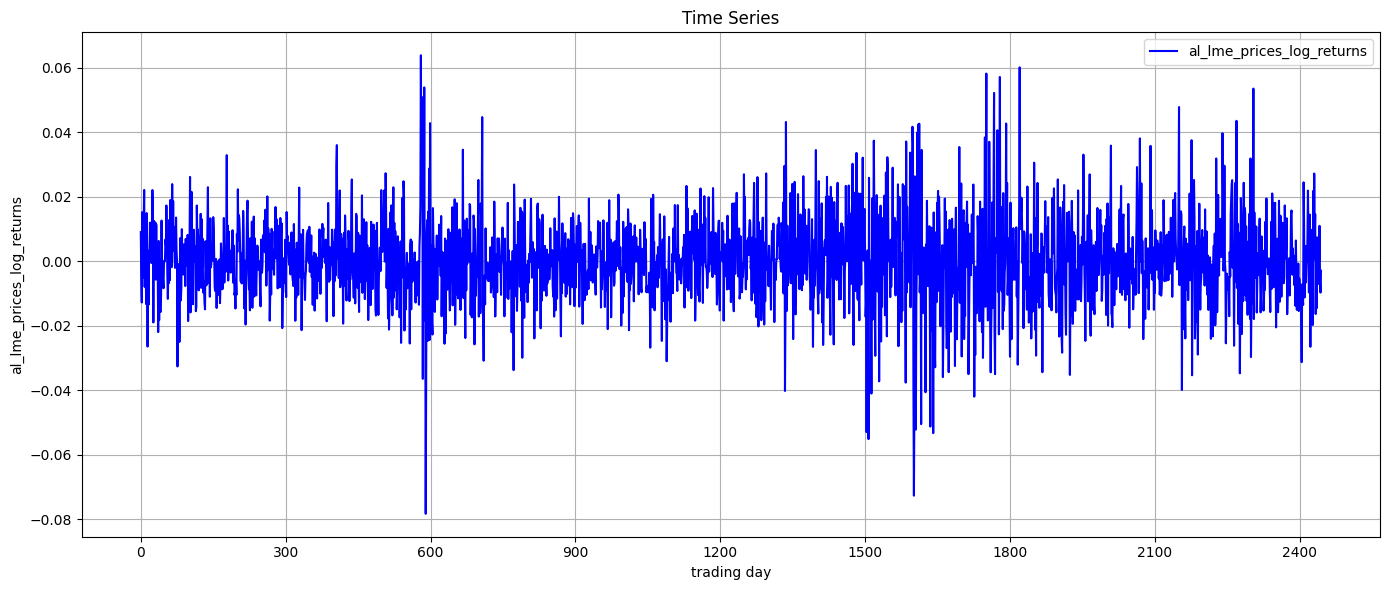

<Axes: title={'center': 'Time Series'}, xlabel='trading day', ylabel='al_lme_prices_log_returns'>

In [4]:
line_plot(df['date'], df['al_lme_prices_log_returns'], 'al_lme_prices_log_returns')

In [5]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=2, q=2)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 1.89604365205786e+19
Iteration:      2,   Func. Count:     23,   Neg. LLF: 825160304332.6484
Iteration:      3,   Func. Count:     40,   Neg. LLF: 4.6253434235242376e+16
Iteration:      4,   Func. Count:     57,   Neg. LLF: 715549484511.7343
Iteration:      5,   Func. Count:     74,   Neg. LLF: 3.59153285539201e+17
Iteration:      6,   Func. Count:     91,   Neg. LLF: 707698034685.4323
Iteration:      7,   Func. Count:    108,   Neg. LLF: 1.6156791951501757e+17
Iteration:      8,   Func. Count:    125,   Neg. LLF: 7423641961604.269
Iteration:      9,   Func. Count:    142,   Neg. LLF: 4.518653745834773e+16
Iteration:     10,   Func. Count:    159,   Neg. LLF: 1.7410201891979642e+16
Iteration:     11,   Func. Count:    173,   Neg. LLF: -7256.4965144121925
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7256.496510377802
            Iterations: 15
            Function evaluations: 173
       

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Constant Mean - GARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GARCH   Log-Likelihood:                7256.50
Distribution:                         Normal   AIC:                          -14501.0
Method:                   Maximum Likelihood   BIC:                          -14466.2
                                               No. Observations:                 2445
Date:                       Mon, Aug 04 2025   Df Residuals:                     2444
Time:                               22:39:33   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.1464e-04  1.634e-04      1.926  5.409e-02 [-5.535e-06,6.348e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      3.5331e-06  1.148e-10  3.076e+04      0.000 [3.533e-06,3.533e-06]
alpha[1]       0.0500  2.520e-02      1.984  4.728e-02 [6.014e-04,9.940e-02]
alpha[2]       0.0500  4.594e-02      1.088      0.276  [-4.005e-02,  0.140]
beta[1]        0.4400      0.764      0.576      0.564     [ -1.057,  1.937]
beta[2]        0.4400      0.723      0.609      0.543     [ -0.976,  1.856]
============================================================================

Covariance estimator: robust
"""

In [6]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=2, q=1)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 3.096579070543469e+19
Iteration:      2,   Func. Count:     20,   Neg. LLF: 476314865.1955645
Iteration:      3,   Func. Count:     33,   Neg. LLF: 1.922731607515672e+23
Iteration:      4,   Func. Count:     49,   Neg. LLF: 71800737710.42169
Iteration:      5,   Func. Count:     58,   Neg. LLF: 1062694073.8375721
Iteration:      6,   Func. Count:     71,   Neg. LLF: 62265947610.817535
Iteration:      7,   Func. Count:     85,   Neg. LLF: 648975967237.1075
Iteration:      8,   Func. Count:    100,   Neg. LLF: -2738.190487300744
Iteration:      9,   Func. Count:    109,   Neg. LLF: 224520377827209.88
Iteration:     10,   Func. Count:    123,   Neg. LLF: -7256.2225994784985
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7256.222600926703
            Iterations: 14
            Function evaluations: 123
            Gradient evaluations: 10




<class 'statsmodels.iolib.summary.Summary'>
"""
                         Constant Mean - GARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GARCH   Log-Likelihood:                7256.22
Distribution:                         Normal   AIC:                          -14502.4
Method:                   Maximum Likelihood   BIC:                          -14473.4
                                               No. Observations:                 2445
Date:                       Mon, Aug 04 2025   Df Residuals:                     2444
Time:                               22:39:36   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.8194e-04  2.417e-04      1.580      0.114 [-9.170e-05,8.556e-04]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      3.5196e-06  1.192e-12  2.953e+06      0.000  [3.520e-06,3.520e-06]
alpha[1]       0.0275  1.981e-02      1.390      0.164 [-1.128e-02,6.635e-02]
alpha[2]       0.0249  1.984e-02      1.255      0.210 [-1.399e-02,6.380e-02]
beta[1]        0.9263  2.908e-03    318.549      0.000      [  0.921,  0.932]
=============================================================================

Covariance estimator: robust
"""

In [7]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=2, q=0)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 389461259.62260467
Iteration:      2,   Func. Count:     18,   Neg. LLF: -7065.873296233498
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7065.873287047682
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2




<class 'statsmodels.iolib.summary.Summary'>
"""
                          Constant Mean - ARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                              ARCH   Log-Likelihood:                7065.87
Distribution:                         Normal   AIC:                          -14123.7
Method:                   Maximum Likelihood   BIC:                          -14100.5
                                               No. Observations:                 2445
Date:                       Mon, Aug 04 2025   Df Residuals:                     2444
Time:                               22:39:38   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.4695e-04  2.734e-04      0.538      0.591 [-3.888e-04,6.827e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      8.8326e-05  3.636e-06     24.289 2.539e-130 [8.120e-05,9.545e-05]
alpha[1]       0.1000  2.162e-02      4.624  3.758e-06   [5.762e-02,  0.142]
alpha[2]       0.1000  2.102e-02      4.756  1.970e-06   [5.879e-02,  0.141]
============================================================================

Covariance estimator: robust
"""

In [8]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=1, q=1)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.785381037053394e+19
Iteration:      2,   Func. Count:     18,   Neg. LLF: 176719254091.15552
Iteration:      3,   Func. Count:     32,   Neg. LLF: 2507788696427.126
Iteration:      4,   Func. Count:     47,   Neg. LLF: 8105588.046827351
Iteration:      5,   Func. Count:     59,   Neg. LLF: -7257.8118957825645
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7257.811903534157
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 5




<class 'statsmodels.iolib.summary.Summary'>
"""
                         Constant Mean - GARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GARCH   Log-Likelihood:                7257.81
Distribution:                         Normal   AIC:                          -14507.6
Method:                   Maximum Likelihood   BIC:                          -14484.4
                                               No. Observations:                 2445
Date:                       Mon, Aug 04 2025   Df Residuals:                     2444
Time:                               22:39:41   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.7775e-04  1.684e-04      1.649  9.915e-02 [-5.238e-05,6.079e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      3.5331e-06  8.384e-13  4.214e+06      0.000 [3.533e-06,3.533e-06]
alpha[1]       0.0500  8.452e-03      5.916  3.306e-09 [3.343e-02,6.657e-02]
beta[1]        0.9300  7.136e-03    130.320      0.000     [  0.916,  0.944]
============================================================================

Covariance estimator: robust
"""

In [20]:
horizon_char = ['1w', '1m', '3m', '1y']
horizon_vals = [5, 22, 66, 252]

In [ ]:
def test_garch(p, q, horizon_char=horizon_char, horizon_vals=horizon_vals):
    hashMap = {i: [] for i in horizon_vals}
    context_window_vals = [5, 10, 20, 50, 100, 200, 500, 1000]
    for i, (horizon_pred, col_name) in enumerate(zip(horizon_vals, horizon_char)):
        losses = []
        for context_window in context_window_vals:
            print(f'{i+1}/{len(horizon_vals)}, cw = {context_window}, horizon = {horizon_vals[i]}')
            
            vols_pred = []
            for idx in tqdm(range(context_window, df.shape[0])):

                returns_window = df['al_lme_prices_log_returns'][idx-context_window:idx]
                model = arch_model(returns_window, vol='Garch', p=p, q=q, dist='normal', mean='constant', rescale=False)
                res = model.fit(disp='off')
                forecast = res.forecast(horizon=horizon_pred)
                
                next_volatility = np.sqrt(forecast.variance.values[0][-1])
                vols_pred.append(next_volatility)

            true_vol = df[f'{col_name}_vol'][context_window:]
            vols_pred = np.array(vols_pred)

            losses.append(mase(true_vol, vols_pred))
            print(context_window, '->', mase(true_vol, vols_pred))
        hashMap[horizon_pred] = losses

    cw_df = pd.DataFrame.from_dict(hashMap)
    cw_df.index = context_window_vals
    cw_df = cw_df.sort_index(axis=1)
    cw_df.to_csv(f'GARCH{p}{q}.csv', index=True)
    print(f'p = {p}, q = {q}\n', cw_df)

In [174]:
values = [(2,2),(2,1),(2,0),(1,1)]

for p, q in values:
    test_garch(p, q)

1/4, cw = 5, horizon = 5


  2%|▏         | 39/2440 [00:00<00:45, 52.71it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  3%|▎         | 85/2440 [00:01<00:41, 56.57it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  8%|▊         | 205/2440 [00:03<00:40, 55.55it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directiona

5 -> 3.7001321802520284
1/4, cw = 10, horizon = 5


  3%|▎         | 72/2435 [00:01<00:40, 58.54it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  4%|▍         | 108/2435 [00:01<00:41, 55.40it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  8%|▊         | 194/2435 [00:03<00:36, 61.49it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message

10 -> 1.3784634304821777
1/4, cw = 20, horizon = 5


...

200 -> nan
4/4, cw = 500, horizon = 252


 42%|████▏     | 824/1945 [00:12<00:14, 75.34it/s] c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 56%|█████▌    | 1094/1945 [00:16<00:12, 67.00it/s]c:\Users\PanSt\Desktop\UCL\T3\Dissertation\Commodity-Optionality-Pricing-UCL-Dissertation\.venv\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
100%|██████████| 1945/1945 [00:29<00:00, 65.33it/s]


500 -> 46.919488997551696
4/4, cw = 1000, horizon = 252


100%|██████████| 1445/1445 [00:20<00:00, 70.78it/s]

1000 -> 65.46821468290166
p = 1, q = 1
            5         22         66         252
5     5.666369       NaN        NaN        NaN
10    1.284808       NaN        NaN        NaN
20    1.591278       NaN        NaN        NaN
50    1.762003  3.973344        NaN        NaN
100   1.827540  5.021096   7.962285        NaN
200   1.822573  5.659540  11.169908        NaN
500   1.822736  6.450884  18.459743  46.919489
1000  1.684611  5.252224  16.843370  65.468215


In [58]:
bestp = 2
bestq = 1

pred_volatilities = {i:[] for i in horizon_char}
avg_pred_volatilities = {i:[] for i in horizon_char}

for i, (horizon_pred, col_name) in enumerate(zip(horizon_vals, horizon_char)):
    context_window = horizon_pred*2
    print(f'{i+1}/{len(horizon_vals)}, cw = {context_window}, horizon = {horizon_vals[i]}')
    
    vols_pred = []
    avg_vols_pred = []
    for idx in tqdm(range(context_window, df.shape[0])):

        returns_window = df['al_lme_prices_log_returns'][idx-context_window:idx]*100
        model = arch_model(returns_window, vol='Garch', p=bestp, q=bestq, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        forecast = res.forecast(horizon=horizon_pred)
        # Take the forecast at the horizon step (last forecast)
        next_volatility = np.sqrt(forecast.variance.values[0][-1])/100
        avg_next_volatility = np.sqrt(np.mean(forecast.variance.values[0]))/100
        vols_pred.append(next_volatility)
        avg_vols_pred.append(avg_next_volatility)

    # true_vol = df[f'{col_name}_vol'][context_window:]
    vols_pred = np.array(vols_pred)   # scale if needed

    pred_volatilities[col_name] = vols_pred
    avg_pred_volatilities[col_name] = avg_vols_pred

with open("pred_volatilities.json", "w") as f:
    json.dump({k: list(map(float, v)) for k, v in pred_volatilities.items()}, f, indent=4)

with open("avg_pred_volatilities.json", "w") as f:
    json.dump({k: list(map(float, v)) for k, v in avg_pred_volatilities.items()}, f, indent=4)

1/4, cw = 10, horizon = 5


100%|██████████| 2435/2435 [00:34<00:00, 71.00it/s]


2/4, cw = 44, horizon = 22


100%|██████████| 2401/2401 [00:34<00:00, 68.71it/s]


3/4, cw = 132, horizon = 66


100%|██████████| 2313/2313 [00:36<00:00, 62.78it/s]


4/4, cw = 504, horizon = 252


100%|██████████| 1941/1941 [00:36<00:00, 52.83it/s]


In [31]:
# metrics
with open("avg_pred_volatilities.json", "r") as f:
    avg_pred_volatilities_test = json.load(f)

In [23]:
metric_names = ['MAPE', 'MAE', 'MSE', 'RMSE', 'MASE']
metrics_df = pd.DataFrame(columns=['Expiry'] + metric_names)

for expiry_date, vals in avg_pred_volatilities_test.items():
    metrics = []
    for metric in [mape, mae, mse, rmse, mase]:
        true_vol = df[f'{expiry_date}_vol'][pred_char_to_value(expiry_date) * 2:]
        assert len(true_vol) == len(vals), f"Length mismatch for {expiry_date}"
        res = metric(vals, true_vol)
        # print(f'{metric.__name__} for {expiry_date}: {res:.4f}')
        metrics.append(res)

    metrics_df.loc[len(metrics_df)] = [expiry_date] + metrics


metrics_df.to_csv('garch_forecast_metrics.csv', index=False)

metrics_df

,Expiry,MAPE,MAE,MSE,RMSE,MASE
0,1w,54.082755,0.002528,0.000014,0.003715,1.035072
1,1m,11.077600,0.001485,0.000010,0.003092,1.673864
2,3m,8.462542,0.001161,0.000003,0.001828,3.478534
3,1y,11.745629,0.001509,0.000004,0.001900,9.272315


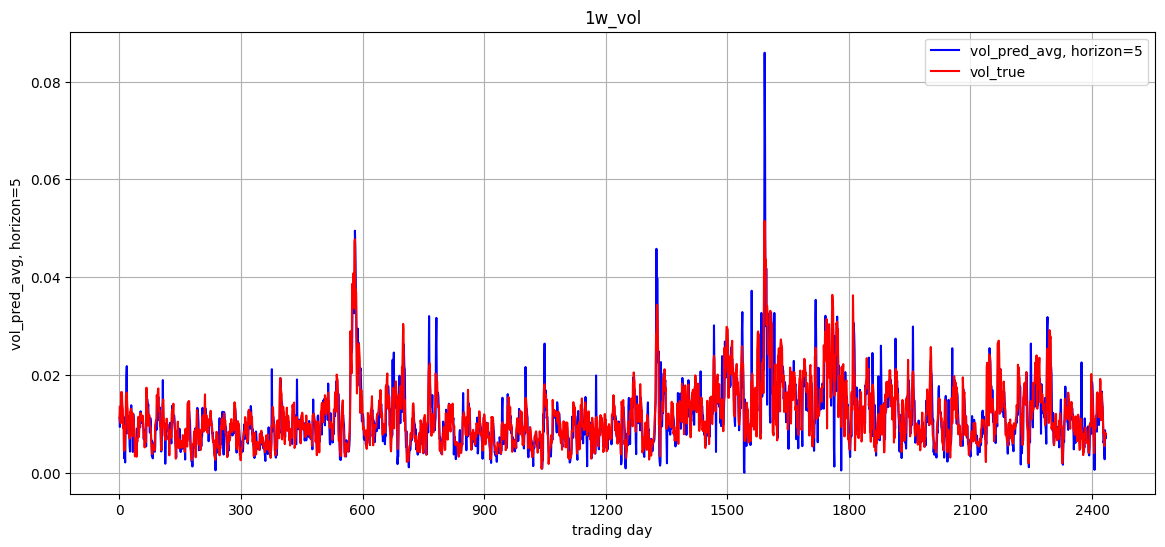

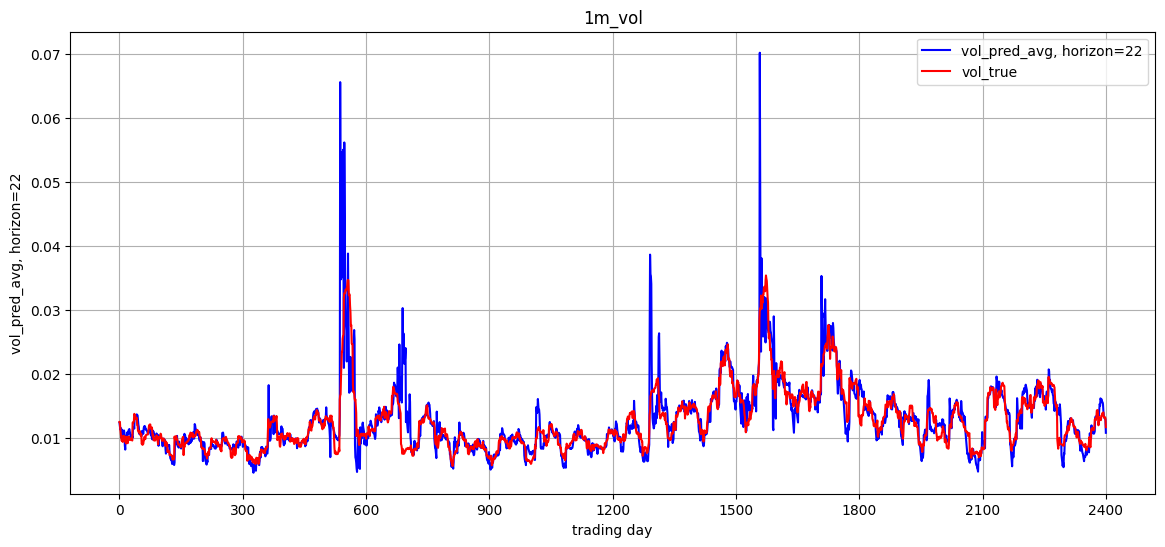

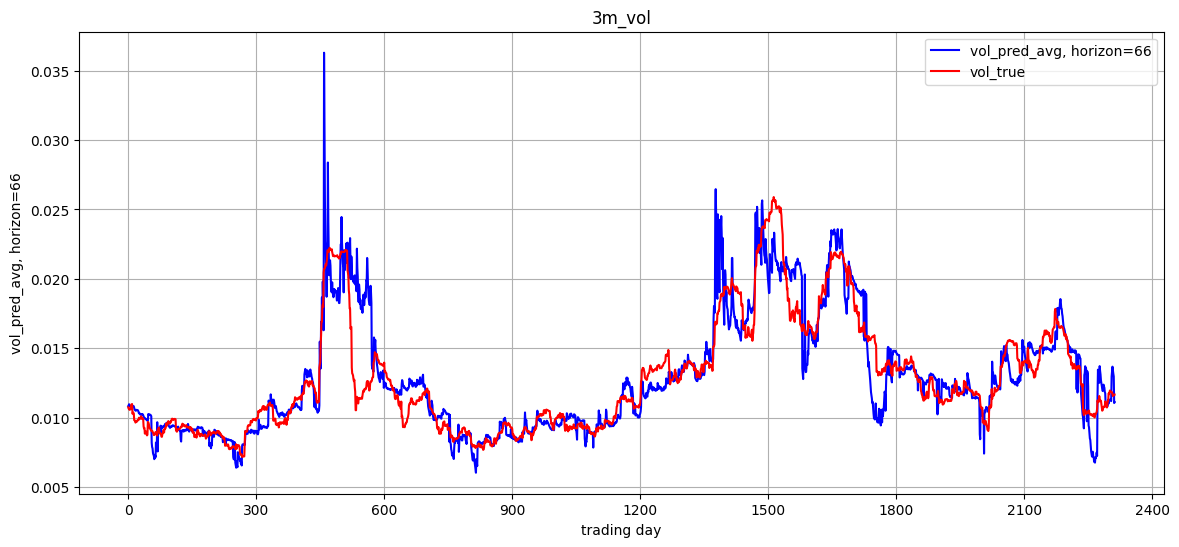

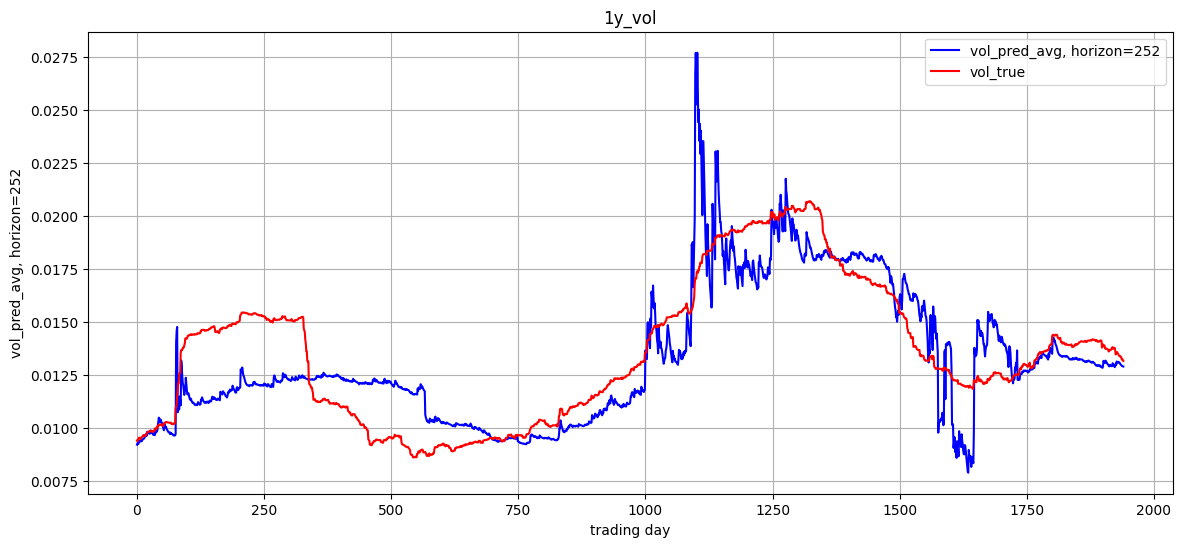

In [24]:
os.makedirs('volatility_plots', exist_ok=True)

for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], vals, f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', graphtitle=f'{expiry_date}_vol', show=False)
    _, _ = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], df[f'{expiry_date}_vol'][2*pred_char_to_value(expiry_date):], 'vol_true', linecolor='red', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_true_garch.png', dpi=300)
    plt.close(fig)

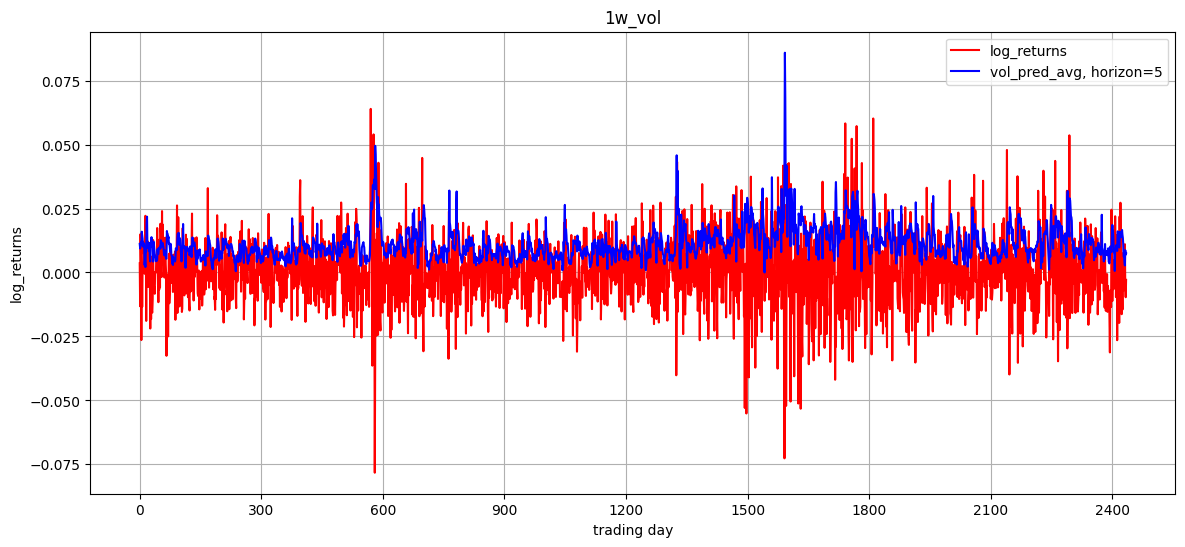

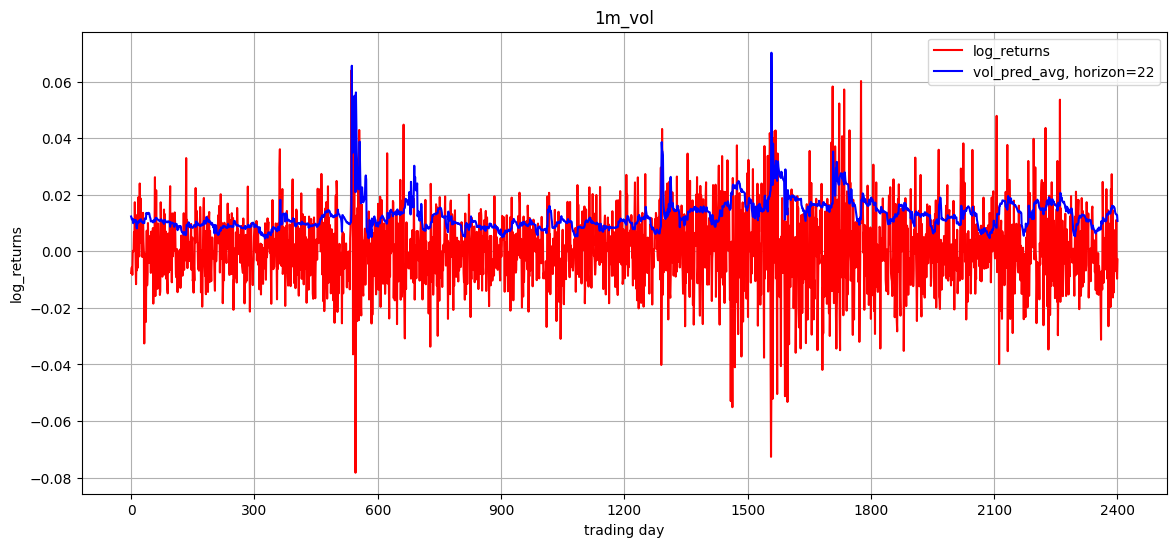

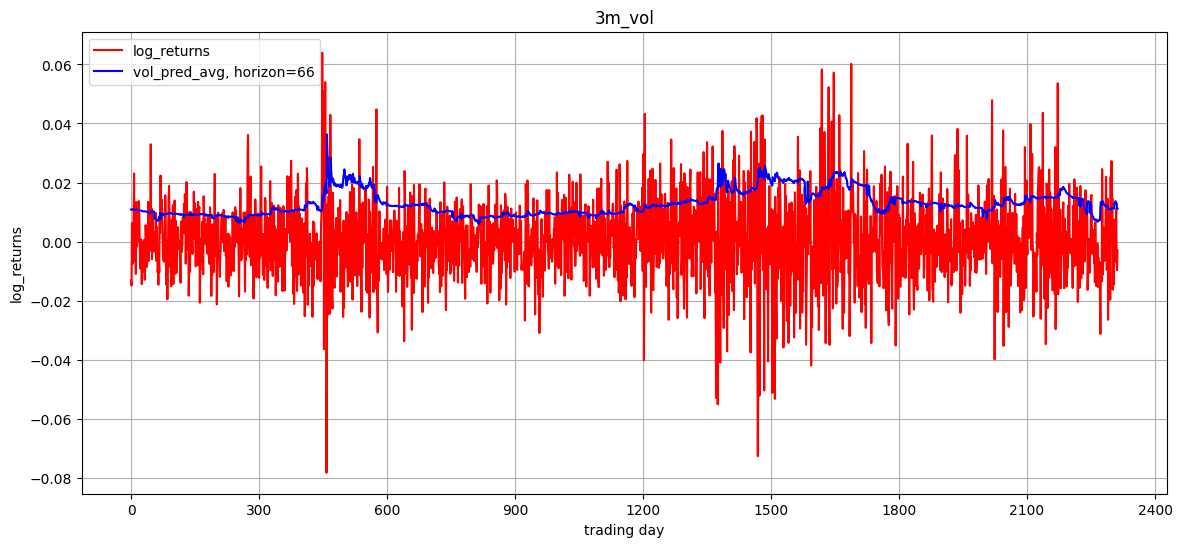

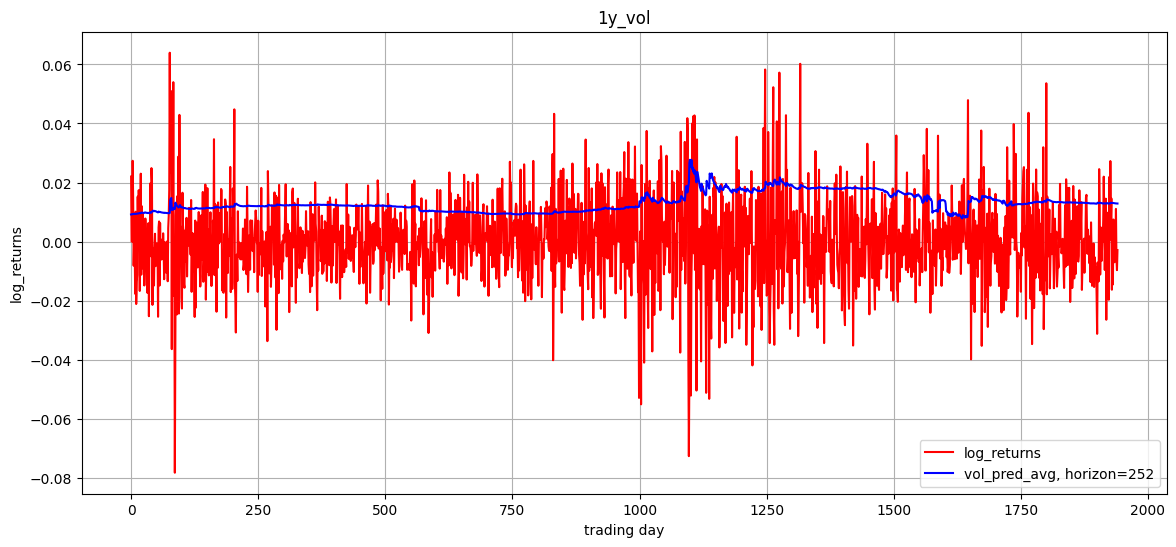

In [25]:
for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], df[f'al_lme_prices_log_returns'][2*pred_char_to_value(expiry_date):], 'log_returns', graphtitle=f'{expiry_date}_vol', linecolor='red', show=False)
    _, _ = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], vals, f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_log_returns_garch.png', dpi=300)
    plt.close(fig)

# Fair metrics - last 20%

In [28]:
# last 488
metric_names = ['MAPE', 'MAE', 'MSE', 'RMSE', 'MASE']
metrics_df = pd.DataFrame(columns=['Expiry'] + metric_names)

for expiry_date, vals in avg_pred_volatilities_test.items():
    metrics = []
    for metric in [mape, mae, mse, rmse, mase]:
        true_vol = df[f'{expiry_date}_vol'][-488+pred_char_to_value(expiry_date):]
        vals = vals[-488+pred_char_to_value(expiry_date):]
        assert len(true_vol) == len(vals), f"Length mismatch for {expiry_date}"
        res = metric(vals, true_vol)
        metrics.append(res)

    metrics_df.loc[len(metrics_df)] = [expiry_date] + metrics


metrics_df.to_csv('garch_forecast_metrics_fair.csv', index=False)

metrics_df

,Expiry,MAPE,MAE,MSE,RMSE,MASE
0,1w,28.608248,0.002460,1.248738e-05,0.003534,1.020863
1,1m,11.578538,0.001286,2.908822e-06,0.001706,1.981958
2,3m,8.744305,0.001043,1.762048e-06,0.001327,3.175788
3,1y,4.640958,0.000612,5.172414e-07,0.000719,8.405413


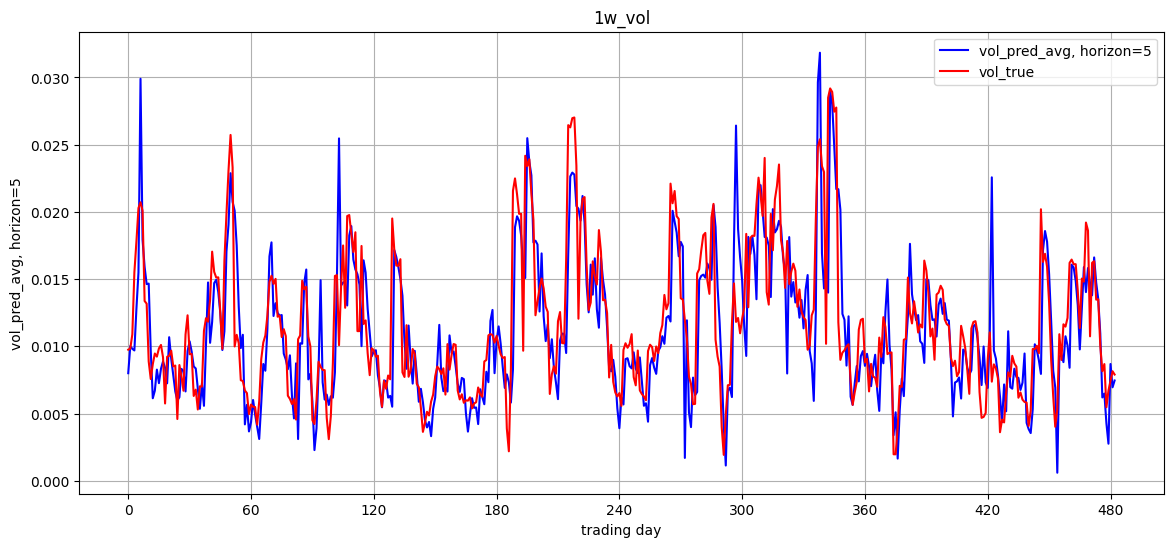

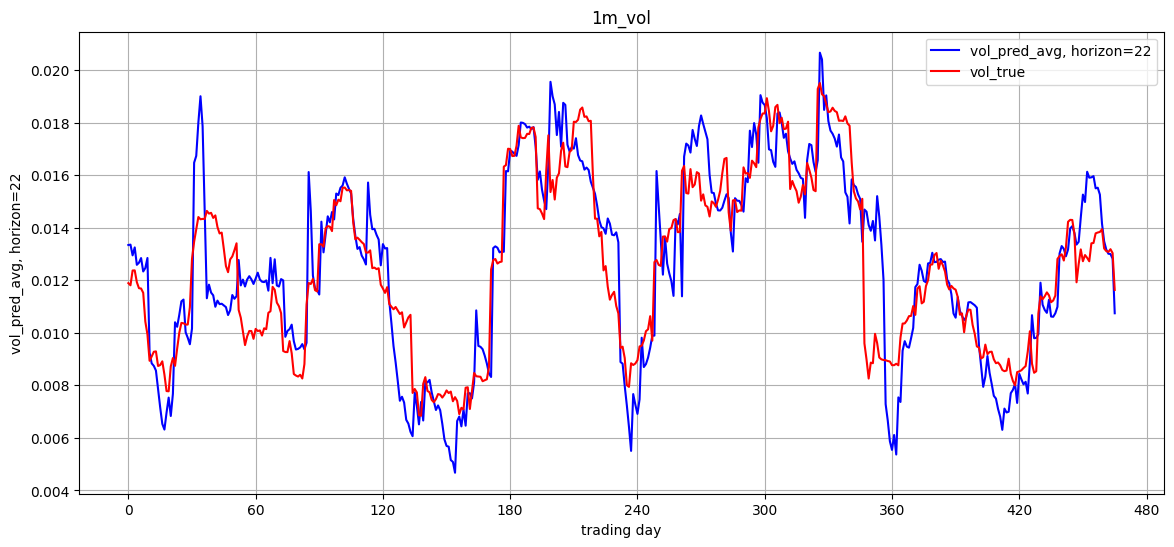

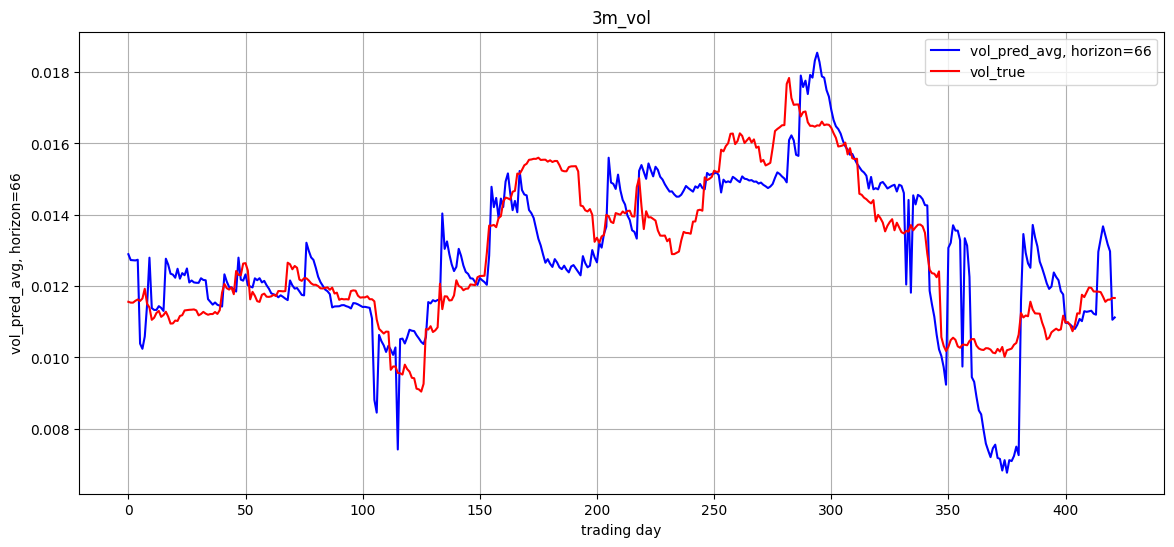

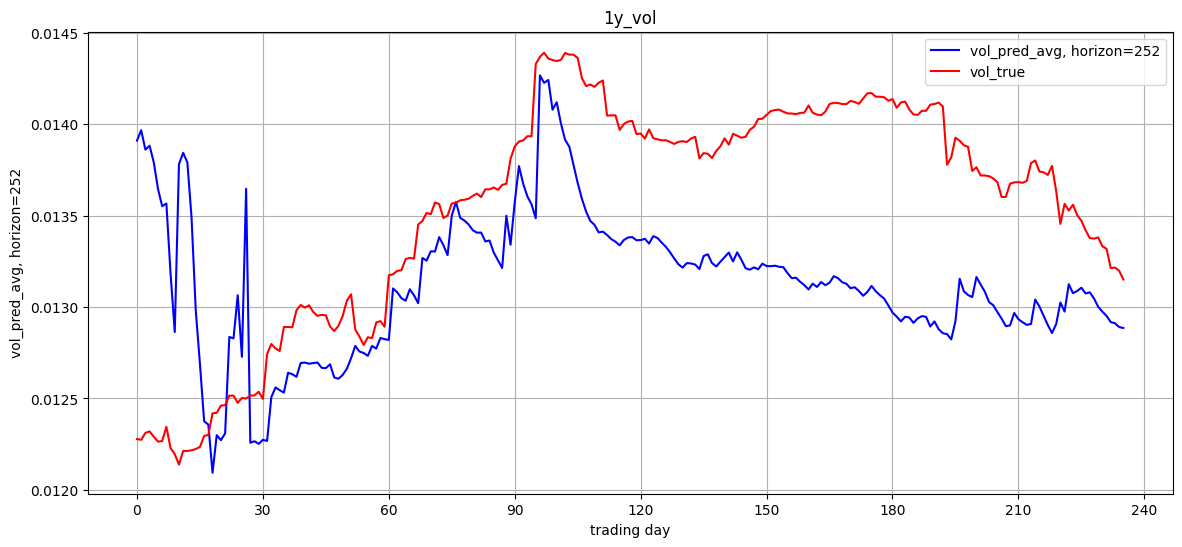

In [29]:
os.makedirs('volatility_plots', exist_ok=True)

for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], vals[-488+pred_char_to_value(expiry_date):], f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', graphtitle=f'{expiry_date}_vol', show=False)
    _, _ = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], df[f'{expiry_date}_vol'][-488+pred_char_to_value(expiry_date):], 'vol_true', linecolor='red', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_true_garch_fair.png', dpi=300)
    plt.close(fig)

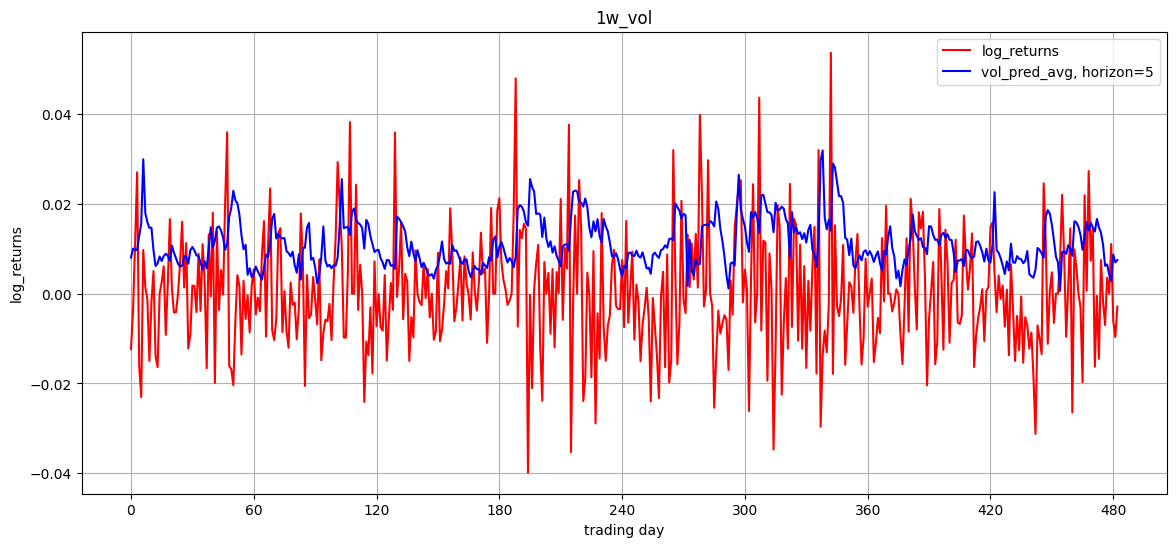

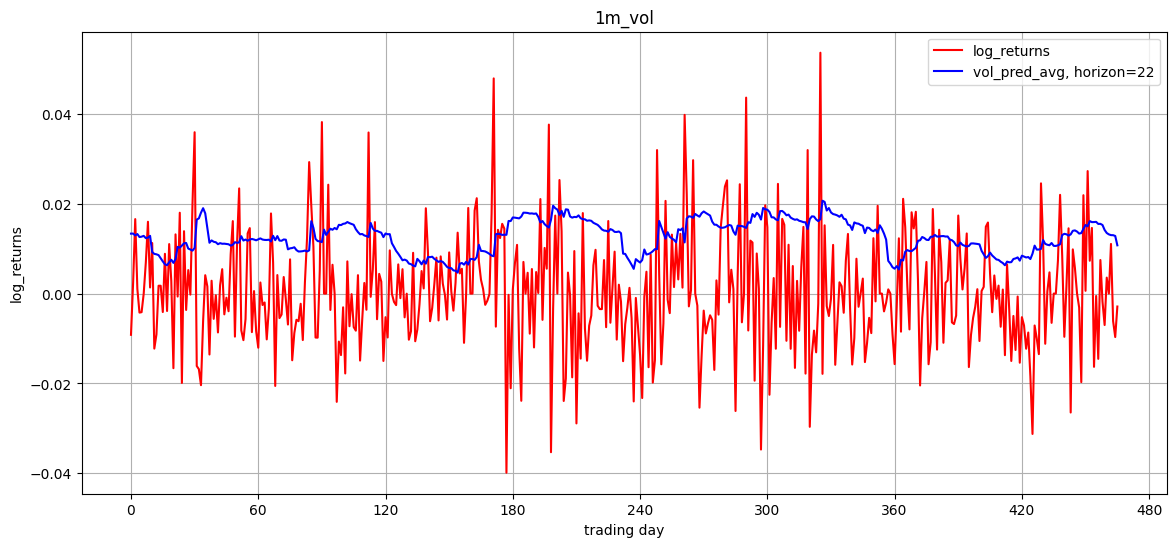

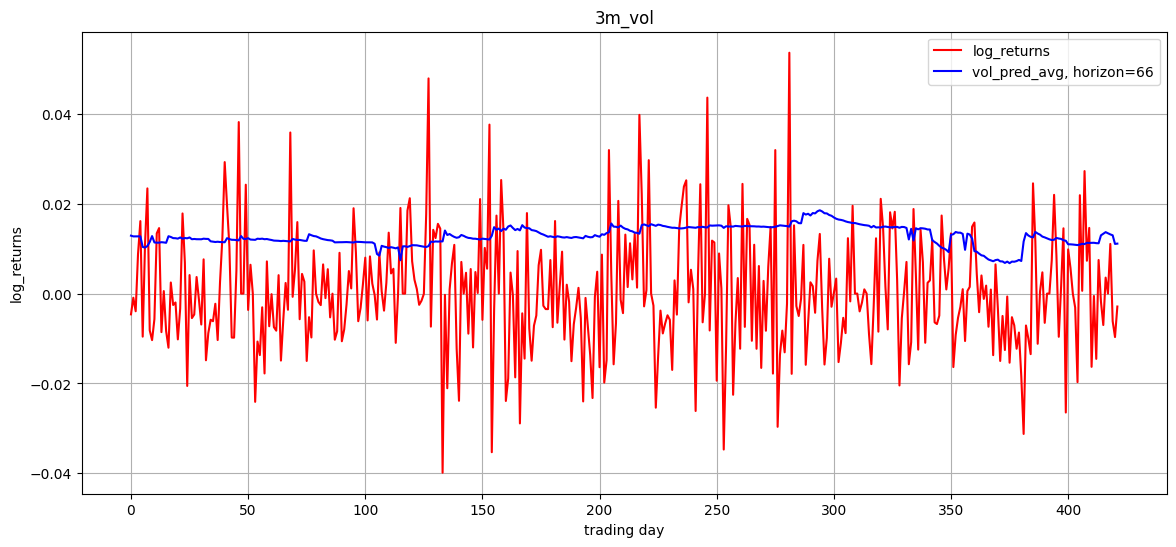

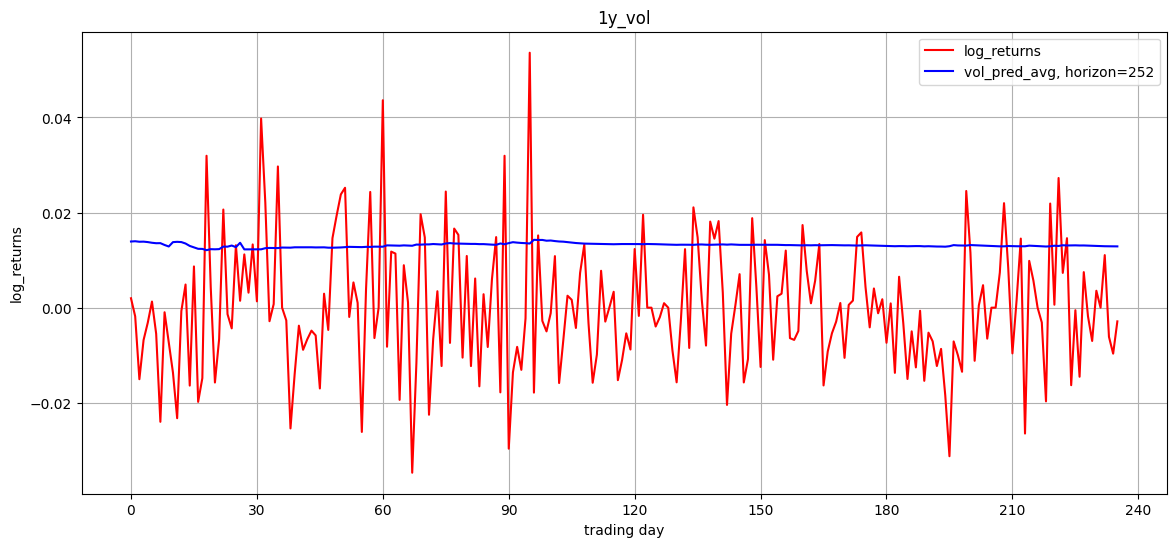

In [30]:
for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], df[f'al_lme_prices_log_returns'][-488+pred_char_to_value(expiry_date):], 'log_returns', graphtitle=f'{expiry_date}_vol', linecolor='red', show=False)
    _, _ = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], vals[-488+pred_char_to_value(expiry_date):], f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_log_returns_garch_fair.png', dpi=300)
    plt.close(fig)